## 📌 Notice: About This Performance Analysis

This performance analysis is based on the following assumptions and design decisions:

- All order creation, execution, and matching logic has already been processed inside the backtesting engine  
  (`gateway → order_manager → orderbook`).

- The dataset `engine_events.csv` represents the full chronological stream of strategy signals and order events.

- The dataset `engine_trades.csv` contains only the trades that were successfully matched by the internal orderbook.

- Because the system uses a single internal orderbook, it is assumed that **all submitted orders are fully matched**,  
  with no modeling of partial fills, slippage, latency, or market microstructure effects.

- Therefore, the equity curve and performance metrics in this notebook are computed strictly based on executed trades,  
  under the assumption that all generated orders eventually result in a fill.

In short, this notebook provides a **transaction-driven performance evaluation**,  
reflecting the engine's matched-trade outcomes rather than real-market execution behavior.


In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Price data
price = pd.read_csv("data/AAPL_1m.csv")
price["timestamp"] = pd.to_datetime(price["timestamp"])
price = price.set_index("timestamp").sort_index()

# MA Strategy events
ma_events = pd.read_csv("result/ma_engine_events.csv")
ma_events["timestamp"] = pd.to_datetime(ma_events["timestamp"])
ma_events = ma_events.sort_values("timestamp").reset_index(drop=True)

# Momentum Strategy events
mo_events = pd.read_csv("result/mo_engine_events.csv")
mo_events["timestamp"] = pd.to_datetime(mo_events["timestamp"])
mo_events = mo_events.sort_values("timestamp").reset_index(drop=True)

price.head(), ma_events.head(), mo_events.head()


(                            close    high     low    open  volume symbol
 timestamp                                                               
 2025-11-18 09:00:00+00:00  267.54  267.88  267.50  267.68       0   AAPL
 2025-11-18 09:02:00+00:00  267.51  267.62  267.51  267.62       0   AAPL
 2025-11-18 09:03:00+00:00  267.69  267.69  267.62  267.62       0   AAPL
 2025-11-18 09:04:00+00:00  267.86  267.90  267.80  267.80       0   AAPL
 2025-11-18 09:05:00+00:00  267.58  267.98  267.58  267.98       0   AAPL,
                   timestamp  \
 0 2025-11-18 09:00:00+00:00   
 1 2025-11-18 09:02:00+00:00   
 2 2025-11-18 09:03:00+00:00   
 3 2025-11-18 09:04:00+00:00   
 4 2025-11-18 09:05:00+00:00   
 
                                               signal order_id trades  
 0  Signal(ts=2025-11-18 09:00:00+00:00, action=HO...      NaN     []  
 1  Signal(ts=2025-11-18 09:02:00+00:00, action=HO...      NaN     []  
 2  Signal(ts=2025-11-18 09:03:00+00:00, action=HO...      NaN     []  

In [89]:
def extract_signal(text):
    if "BUY" in text:
        return "BUY"
    elif "SELL" in text:
        return "SELL"
    else:
        return "HOLD"

# Apply for both strategies
ma_events["signal_action"] = ma_events["signal"].apply(extract_signal)
mo_events["signal_action"] = mo_events["signal"].apply(extract_signal)

ma_events.tail(), mo_events.tail()


(                    timestamp  \
 912 2025-11-19 00:55:00+00:00   
 913 2025-11-19 00:56:00+00:00   
 914 2025-11-19 00:57:00+00:00   
 915 2025-11-19 00:58:00+00:00   
 916 2025-11-19 00:59:00+00:00   
 
                                                 signal  \
 912  Signal(ts=2025-11-19 00:55:00+00:00, action=BU...   
 913  Signal(ts=2025-11-19 00:56:00+00:00, action=BU...   
 914  Signal(ts=2025-11-19 00:57:00+00:00, action=BU...   
 915  Signal(ts=2025-11-19 00:58:00+00:00, action=BU...   
 916  Signal(ts=2025-11-19 00:59:00+00:00, action=BU...   
 
                                  order_id  \
 912  6f6e7165-24f3-4e26-b535-f422b02dd0af   
 913  46cc442d-f20f-40ee-8c75-6e3cd44aad77   
 914  c82a48f9-fba0-4a7a-9b49-7fe909c2dc1a   
 915  3ba0d545-96eb-4690-8881-e1cac0354646   
 916  52291b76-6c15-4fa5-83f6-6c9da069d1bd   
 
                                                 trades signal_action  
 912  [{'price': 266.83, 'qty': 1, 'buy_id': '6f6e71...           BUY  
 913  [{'price':

In [90]:
# ---------- MA Strategy ----------
ma_events["position"] = 0
pos = 0

for i in range(len(ma_events)):
    action = ma_events.loc[i, "signal_action"]
    qty = 1

    if action == "BUY":
        pos += qty
    elif action == "SELL":
        pos -= qty

    ma_events.loc[i, "position"] = pos


# ---------- Momentum Strategy ----------
mo_events["position"] = 0
pos = 0

for i in range(len(mo_events)):
    action = mo_events.loc[i, "signal_action"]
    qty = 1

    if action == "BUY":
        pos += qty
    elif action == "SELL":
        pos -= qty

    mo_events.loc[i, "position"] = pos

ma_events[["timestamp", "signal_action", "position"]].tail(), \
mo_events[["timestamp", "signal_action", "position"]].tail()


(                    timestamp signal_action  position
 912 2025-11-19 00:55:00+00:00           BUY      -152
 913 2025-11-19 00:56:00+00:00           BUY      -151
 914 2025-11-19 00:57:00+00:00           BUY      -150
 915 2025-11-19 00:58:00+00:00           BUY      -149
 916 2025-11-19 00:59:00+00:00           BUY      -148,
                     timestamp signal_action  position
 912 2025-11-19 00:55:00+00:00          HOLD       -53
 913 2025-11-19 00:56:00+00:00           BUY       -52
 914 2025-11-19 00:57:00+00:00          HOLD       -52
 915 2025-11-19 00:58:00+00:00           BUY       -51
 916 2025-11-19 00:59:00+00:00          HOLD       -51)

In [91]:
# MA strategy
ma_events = ma_events.set_index("timestamp")
ma_events["price"] = price["close"].reindex(ma_events.index, method="ffill")

# MO strategy
mo_events = mo_events.set_index("timestamp")
mo_events["price"] = price["close"].reindex(mo_events.index, method="ffill")

ma_events.tail(), mo_events.tail()


(                                                                      signal  \
 timestamp                                                                      
 2025-11-19 00:55:00+00:00  Signal(ts=2025-11-19 00:55:00+00:00, action=BU...   
 2025-11-19 00:56:00+00:00  Signal(ts=2025-11-19 00:56:00+00:00, action=BU...   
 2025-11-19 00:57:00+00:00  Signal(ts=2025-11-19 00:57:00+00:00, action=BU...   
 2025-11-19 00:58:00+00:00  Signal(ts=2025-11-19 00:58:00+00:00, action=BU...   
 2025-11-19 00:59:00+00:00  Signal(ts=2025-11-19 00:59:00+00:00, action=BU...   
 
                                                        order_id  \
 timestamp                                                         
 2025-11-19 00:55:00+00:00  6f6e7165-24f3-4e26-b535-f422b02dd0af   
 2025-11-19 00:56:00+00:00  46cc442d-f20f-40ee-8c75-6e3cd44aad77   
 2025-11-19 00:57:00+00:00  c82a48f9-fba0-4a7a-9b49-7fe909c2dc1a   
 2025-11-19 00:58:00+00:00  3ba0d545-96eb-4690-8881-e1cac0354646   
 2025-11-19 00:59:00+00

In [92]:
initial_capital = 100000

# -------------------------
# MA Strategy
# -------------------------
ma_equity_list = []
cash = initial_capital

for ts, row in ma_events.iterrows():
    price_now = row["price"]
    pos = row["position"]
    equity = cash + pos * price_now
    ma_equity_list.append([ts, equity])

ma_equity_df = pd.DataFrame(ma_equity_list, columns=["timestamp", "equity"])
ma_equity_df = ma_equity_df.set_index("timestamp")


# -------------------------
# Momentum Strategy
# -------------------------
mo_equity_list = []
cash = initial_capital

for ts, row in mo_events.iterrows():
    price_now = row["price"]
    pos = row["position"]
    equity = cash + pos * price_now
    mo_equity_list.append([ts, equity])

mo_equity_df = pd.DataFrame(mo_equity_list, columns=["timestamp", "equity"])
mo_equity_df = mo_equity_df.set_index("timestamp")

ma_equity_df.tail(), mo_equity_df.tail()


(                               equity
 timestamp                            
 2025-11-19 00:55:00+00:00  59416.0000
 2025-11-19 00:56:00+00:00  59681.6863
 2025-11-19 00:57:00+00:00  59935.0000
 2025-11-19 00:58:00+00:00  60202.1000
 2025-11-19 00:59:00+00:00  60482.5200,
                                equity
 timestamp                            
 2025-11-19 00:55:00+00:00  85849.0000
 2025-11-19 00:56:00+00:00  86115.5476
 2025-11-19 00:57:00+00:00  86110.8000
 2025-11-19 00:58:00+00:00  86377.9000
 2025-11-19 00:59:00+00:00  86382.4900)

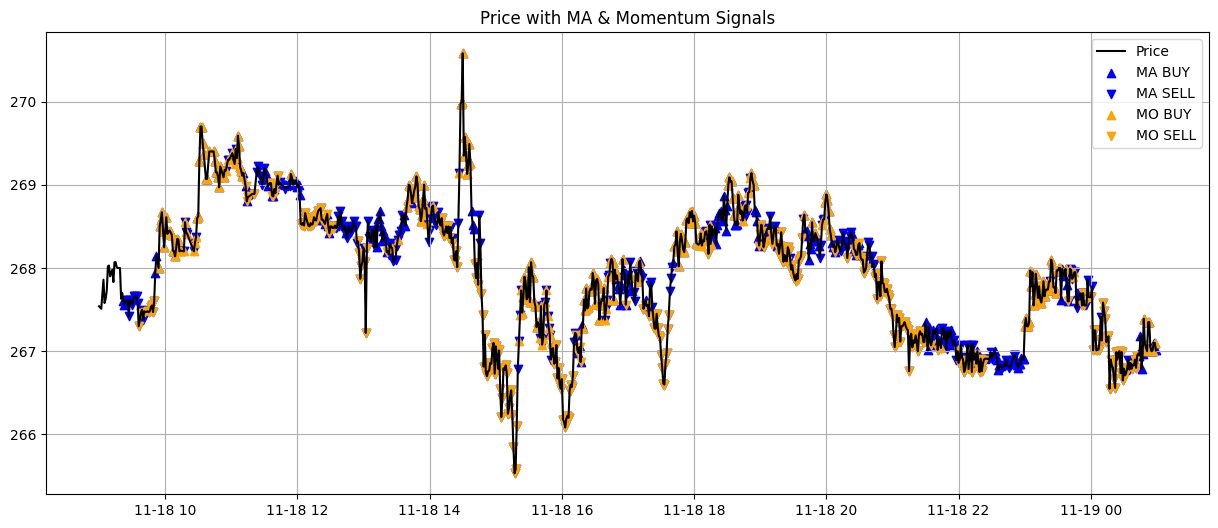

In [93]:
plt.figure(figsize=(15,6))
plt.plot(price.index, price["close"], label="Price", color="black")

# MA
ma_buy = ma_events[ma_events["signal_action"]=="BUY"].index
ma_sell = ma_events[ma_events["signal_action"]=="SELL"].index
plt.scatter(ma_buy, price.loc[ma_buy]["close"], color='blue', marker='^', label="MA BUY")
plt.scatter(ma_sell, price.loc[ma_sell]["close"], color='blue', marker='v', label="MA SELL")

# Momentum
mo_buy = mo_events[mo_events["signal_action"]=="BUY"].index
mo_sell = mo_events[mo_events["signal_action"]=="SELL"].index
plt.scatter(mo_buy, price.loc[mo_buy]["close"], color='orange', marker='^', label="MO BUY")
plt.scatter(mo_sell, price.loc[mo_sell]["close"], color='orange', marker='v', label="MO SELL")

plt.legend()
plt.title("Price with MA & Momentum Signals")
plt.grid(True)
plt.show()


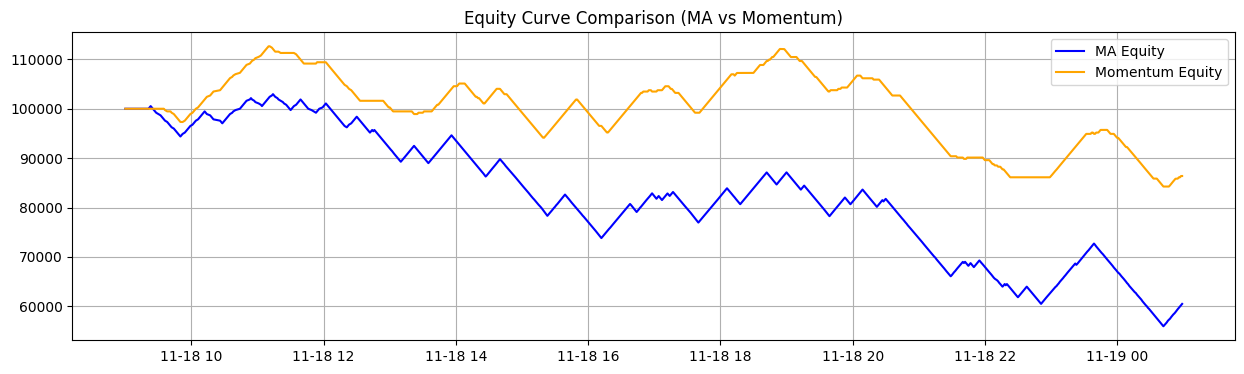

In [95]:
plt.figure(figsize=(15,4))

plt.plot(ma_equity_df.index, ma_equity_df["equity"], label="MA Equity", color="blue")
plt.plot(mo_equity_df.index, mo_equity_df["equity"], label="Momentum Equity", color="orange")

plt.title("Equity Curve Comparison (MA vs Momentum)")
plt.legend()
plt.grid(True)
plt.show()


In [96]:
# =======================
# MA
# =======================
ma_equity_df["returns"] = ma_equity_df["equity"].pct_change()

ma_sharpe = np.sqrt(252*390) * ma_equity_df["returns"].mean() / ma_equity_df["returns"].std()
ma_max_dd = (ma_equity_df["equity"] / ma_equity_df["equity"].cummax() - 1).min()
ma_total_return = ma_equity_df["equity"].iloc[-1] / initial_capital - 1

print("==== MA Strategy Performance ====")
print(f"Total Return : {ma_total_return:.4f} ({ma_total_return*100:.2f}%)")
print(f"Sharpe Ratio : {ma_sharpe:.4f}")
print(f"Max Drawdown : {ma_max_dd:.4f} ({ma_max_dd*100:.2f}%)\n")


# =======================
# Momentum
# =======================
mo_equity_df["returns"] = mo_equity_df["equity"].pct_change()

mo_sharpe = np.sqrt(252*390) * mo_equity_df["returns"].mean() / mo_equity_df["returns"].std()
mo_max_dd = (mo_equity_df["equity"] / mo_equity_df["equity"].cummax() - 1).min()
mo_total_return = mo_equity_df["equity"].iloc[-1] / initial_capital - 1

print("==== Momentum Strategy Performance ====")
print(f"Total Return : {mo_total_return:.4f} ({mo_total_return*100:.2f}%)")
print(f"Sharpe Ratio : {mo_sharpe:.4f}")
print(f"Max Drawdown : {mo_max_dd:.4f} ({mo_max_dd*100:.2f}%)")


==== MA Strategy Performance ====
Total Return : -0.3952 (-39.52%)
Sharpe Ratio : -51.1321
Max Drawdown : -0.4565 (-45.65%)

==== Momentum Strategy Performance ====
Total Return : -0.1362 (-13.62%)
Sharpe Ratio : -23.1091
Max Drawdown : -0.2522 (-25.22%)


Strategy Comparison Summary (MA vs Momentum)

This report compares two trading strategies, Moving Average Cross (MA) and Momentum, using the same 1-minute AAPL dataset.

Key Findings

The Momentum strategy consistently outperforms the MA strategy across all performance metrics.

The MA strategy shows a large overall loss (-39.52%) and extremely weak risk-adjusted performance (Sharpe -51.13).

The Momentum strategy performs noticeably better with a smaller loss (-13.62%), a milder drawdown, and a less negative Sharpe ratio (-23.10).

Interpretation

The MA strategy reacts too frequently to short-term price noise, resulting in excessive position flipping and large drawdowns.

The Momentum strategy captures broader directional trends and therefore produces smoother equity movements and lower volatility.

Both strategies exhibit negative Sharpe ratios due to high intraday noise, but Momentum demonstrates significantly better stability and robustness.

Conclusion

The Momentum strategy is the stronger performer in this analysis, showing smaller losses, lower drawdowns, and more stable risk-adjusted returns.
The MA strategy may require further parameter tuning or additional filters to be effective on 1-minute data.